# Producing a Liklihood scan using IceCube 14-year public data

This tutorial shows how to produce a liklihood scan using SkyLLH. 

In [1]:
import sys

import numpy as np
import scipy.stats
from matplotlib import pyplot as plt

sys.path.append('/Users/amithan/skyllh_14/skyllh')

For a more details on the ``create_dataset_collection``, ``PointLikeSource``, ``create_analysis``, ``initialize_trial`` and ``unblind`` functions see 'here the url for the 14 year tutorial'.

First we have to create a configuration instance.

In [3]:
from skyllh.core.config import Config

cfg = Config()

Importing dataset definition of the public 14-year point-source data set and we can get a list of data sets via the access operator ``[dataset1, dataset2, ...]`` of the ``dsc`` instance:  For more details on the ``create_dataset_collection`` function see 'url'

In [ ]:
from skyllh.datasets.i3.PublicData_14y_ps import create_dataset_collection

dsc = create_dataset_collection(cfg=cfg, base_path='/Users/amithan/Downloads/', sub_path_fmt='PublicData_14y')
print(dsc.dataset_names)
datasets = dsc['IC40', 'IC59', 'IC79', 'IC86_I-XI']

['IC40', 'IC59', 'IC79', 'IC86_I', 'IC86_I-XI', 'IC86_II', 'IC86_III', 'IC86_IV', 'IC86_IX', 'IC86_V', 'IC86_VI', 'IC86_VII', 'IC86_VIII', 'IC86_X', 'IC86_XI']


Defining the Source: Here we use NGC 1068 as the source

Once the source is defined the ``create_analysis`` function can create the analysis instance

In [ ]:
from skyllh.analyses.i3.publicdata_ps.time_integrated_ps import create_analysis
from skyllh.core.source_model import PointLikeSource

src_ra = 40.67  # degrees
src_dec = -0.01  # degrees

source = PointLikeSource(ra=np.radians(src_ra), dec=np.radians(src_dec))

ana = create_analysis(cfg=cfg, datasets=datasets, source=source)

100%|██████████| 136/136 [00:00<00:00, 2140.32it/s]


Initializing the analysis instance and unbliding the data.

In [ ]:
from skyllh.core.random import RandomStateService

rss = RandomStateService(3090)
TS, bestfit_params, minimizer_status = ana.unblind(rss)
ns_bf = bestfit_params['ns']
gamma_bf = bestfit_params['gamma']
print(f'Unblinded results: TS={TS:.2f}, ns={ns_bf:.2f}, gamma={gamma_bf:.2f}')
print(f'Minimizer status: {minimizer_status}')

In [10]:
events_list = [data.exp for data in ana.data_list]
ana.initialize_trial(events_list)

In [14]:
from skyllh.core.random import RandomStateService

rss = RandomStateService(seed=1)

In [15]:
(ts, x, status) = ana.unblind(rss)

print(f'TS = {ts:.3f}')
print(f'ns = {x["ns"]:.2f}')
print(f'gamma = {x["gamma"]:.2f}')

TS = 29.154
ns = 80.09
gamma = 3.21


## Evaluating the log-likelihood ratio function

Sometimes it is useful to be able to evaluate the log-likelihood ratio function, e.g. for creating a likelihood contour plot. Because SkyLLH's structure is based on the mathematical structure of the likelihood function, the `Analysis` instance has the property `llhratio` which is the class instance of the used log-likelihood ratio function. This instance has the method `evaluate`. The method takes an array of the fit parameter values as argument at which the LLH ratio function will be evaluated. It returns the value of the LLH ratio function at the given point and its gradients w.r.t. the fit parameters.

In our case this is the number of signal events, $n_{\mathrm{s}}$ and the spectral index $\gamma$. If we evaluate the LLH ratio function at the maximum, the gradients should be close to zero.

In [8]:
help(ana.llhratio.evaluate)

Help on method evaluate in module skyllh.core.llhratio:

evaluate(fitparam_values, src_params_recarray=None, tl=None) method of skyllh.core.llhratio.MultiDatasetTCLLHRatio instance
    Evaluates the composite log-likelihood-ratio function and returns its
    value and global fit parameter gradients.
    
    Parameters
    ----------
    fitparam_values : instance of numpy ndarray
        The (N_fitparams,)-shaped numpy 1D ndarray holding the current
        values of the global fit parameters.
    src_params_recarray : instance of numpy record ndarray | None
        The numpy record ndarray of length N_sources holding the parameter
        names and values of all sources.
        See the documentation of the
        :meth:`skyllh.core.parameters.ParameterModelMapper.create_src_params_recarray`
        method for more information about this array.
        It case it is ``None``, it will be created automatically from the
        ``fitparam_values`` argument using the
        :class:`~sk

In [11]:
(llhratio_value, (grad_ns, grad_gamma)) = ana.llhratio.evaluate([80.09, 3.21])
print(f'llhratio_value = {llhratio_value:.3f}')
print(f'grad_ns = {grad_ns:.3f}')
print(f'grad_gamma = {grad_gamma:.3f}')

llhratio_value = 14.577
grad_ns = 0.000
grad_gamma = -0.021


Using the `evaluate` method of the `LLHRatio` class we can scan the log-likelihood ratio space and create a contour plot showing the best fit and the 68%, 90%, and 95% quantile assuming Wilks-theorem.

In [16]:
(flux_min, flux_max, flux_step) = (-15, -12, 0.05)
(gamma_min, gamma_max, gamma_step) = (2.0, 4.0, 0.05)

flux_edges = np.logspace(flux_min, flux_max, int((flux_max - flux_min) / flux_step) + 1)
flux_vals = 0.5 * (flux_edges[1:] + flux_edges[:-1])

gamma_edges_flux = np.linspace(gamma_min, gamma_max, int((gamma_max - gamma_min) / gamma_step + 1))
gamma_vals_flux = 0.5 * (gamma_edges_flux[1:] + gamma_edges_flux[:-1])

flux_scaling_factor = ana.calculate_fluxmodel_scaling_factor(1, [x['ns'], x['gamma']])

delta_ts_flux = np.empty((len(flux_vals), len(gamma_vals_flux)), dtype=np.double)
for flux_i, flux in enumerate(flux_vals):
    ns = flux / flux_scaling_factor
    for gamma_i, gamma in enumerate(gamma_vals_flux):
        delta_ts_flux[flux_i, gamma_i] = ana.calculate_test_statistic(
            ana.llhratio.evaluate([x['ns'], x['gamma']])[0], [x['ns'], x['gamma']]
        ) - ana.calculate_test_statistic(ana.llhratio.evaluate([ns, gamma])[0], [ns, gamma])

# Determine the best fit flux and gamma values from the scan.
index_max = np.argmin(delta_ts_flux)
flux_i_max = int(index_max / len(gamma_vals_flux))
gamma_i_max_flux = index_max % len(gamma_vals_flux)
flux_best = flux_vals[flux_i_max]
gamma_best_flux = gamma_vals_flux[gamma_i_max_flux]

In [17]:
chi2_68_quantile_flux = scipy.stats.chi2.ppf(0.68, df=2)
chi2_90_quantile_flux = scipy.stats.chi2.ppf(0.90, df=2)
chi2_95_quantile_flux = scipy.stats.chi2.ppf(0.95, df=2)

The contours are computed assuming that the Wilks theorem holds true. That is the TS distribution follows the $\chi^2$ distribution with 2 degrees of freedom

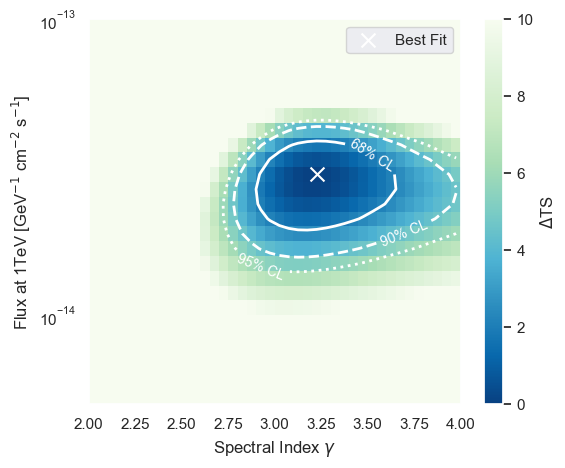

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
im = ax.pcolormesh(gamma_edges_flux, flux_edges, delta_ts_flux, vmin=0, vmax=10, cmap='GnBu_r')
cbar = plt.colorbar(im)
cbar.set_label(r'$\Delta$TS')

ax.scatter([gamma_best_flux], [flux_best], color='w', marker='x', s=100, label='Best Fit')
contour_68 = ax.contour(
    gamma_vals_flux, flux_vals, delta_ts_flux, levels=[chi2_68_quantile_flux], colors='w', linestyles='-', linewidths=2
)
contour_90 = ax.contour(
    gamma_vals_flux, flux_vals, delta_ts_flux, levels=[chi2_90_quantile_flux], colors='w', linestyles='--', linewidths=2
)
contour_95 = ax.contour(
    gamma_vals_flux, flux_vals, delta_ts_flux, levels=[chi2_95_quantile_flux], colors='w', linestyles=':', linewidths=2
)

ax.set_xlabel(r'Spectral Index $\gamma$')
ax.set_ylabel(r'Flux at 1TeV [GeV$^{-1}$ cm$^{-2}$ s$^{-1}$]')

ax.set_yscale('log')
ax.set_ylim(5e-15, 1e-13)

ax.clabel(contour_68, fmt={chi2_68_quantile_flux: '68% CL'}, fontsize=10, inline=True, inline_spacing=5, manual=False)

ax.clabel(contour_90, fmt={chi2_90_quantile_flux: '90% CL'}, fontsize=10, inline=True, inline_spacing=5, manual=False)

ax.clabel(contour_95, fmt={chi2_95_quantile_flux: '95% CL'}, fontsize=10, inline=True, inline_spacing=5, manual=False)


plt.legend(loc='upper right')
plt.show()